### **`GROUP 4 PROJECT`**
***
## Group Members
----
1. Abdullahi Hassan
2. Lauren Kuria
3. Yvonne Rajula 
4. Dahir Mohamed
5. Samantha jepkosgei
6. Claire njeri
---

# Phase 4 Final: Advanced Sentiment Analysis for Apple & Google
---

## 1. Business Understanding
---
### Project Overview
This project focuses on building an advanced **Natural Language Processing (NLP)** sentiment classifier for major tech brands. Using a dataset of tweets collected during the **SXSW (South by Southwest)** conference, we aim to automate the process of understanding public sentiment toward Apple and Google products.

---

### The Stakeholder
The primary stakeholders are the **Customer Success and Branding Teams** at **Apple** and **Google**. These departments are responsible for:
* Monitoring brand reputation in real-time.
* Identifying product bugs or service outages reported by users.
* Engaging with the community to mitigate public relations crises.
---
### The Business Problem
High-profile events like SXSW generate a massive volume of social media activity. For stakeholders, this presents several challenges:
1. **Scalability:** The sheer volume of tweets (thousands per hour) makes manual human moderation impossible.
2. **Noise vs. Signal:** Most tweets are neutral or "no emotion." However, **negative sentiment** often signals critical issues like app crashes ("crashy"), hardware failures ("dead battery"), or poor customer service.
3. **Reaction Time:** In the age of viral social media, a delay of even a few hours in addressing a widespread complaint can lead to significant brand damage.

----

### Objective
The goal is to develop a multiclass sentiment classifier that can:
* **Automatically categorize** tweets into Positive, Negative, or Neutral sentiment.
* **Prioritize Negative Feedback:** The model must achieve high **Recall** for the "Negative Emotion" class to ensure the Branding Team never misses a critical customer complaint.
* **Inform Strategy:** By analyzing the most predictive words (features), we provide stakeholders with actionable data on *why* customers are dissatisfied.

----

### Success Criteria
Success is defined by the model's ability to accurately distinguish negative sentiment from the majority (neutral) class. We will evaluate performance using the **RECALL OF 0.80** and a **Confusion Matrix**, specifically monitoring for low False Negatives in the negative sentiment category.
***

## Introduction

The goal of this project is to build a Natural Language Processing (NLP) model that classifies text into three sentiment categories:

- Negative emotion  
- Positive emotion  
- No emotion toward brand or product  

This is a **multi-class classification problem** with imbalanced data, where some classes appear more frequently than others.

To solve this, we apply:
- Text preprocessing
- TF-IDF vectorization
- Multiple machine learning models
- Model evaluation and comparison
- Threshold tuning to maximize recall for the minority negative class
***

In [1]:
# ===================== IMPORT LIBRARIES =====================
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Data Understanding

In [2]:
df = pd.read_csv('judge_1377884607_tweet_product_company.csv', encoding='latin1')

df = df.rename(columns={
    "tweet_text": "text",
    "emotion_in_tweet_is_directed_at": "product",
    "is_there_an_emotion_directed_at_a_brand_or_product": "sentiment"
})

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['sentiment'].value_counts(normalize=True))

Dataset Shape: (8721, 3)

Class Distribution:
sentiment
No emotion toward brand or product    0.591217
Positive emotion                      0.328976
Negative emotion                      0.062493
I can't tell                          0.017315
Name: proportion, dtype: float64


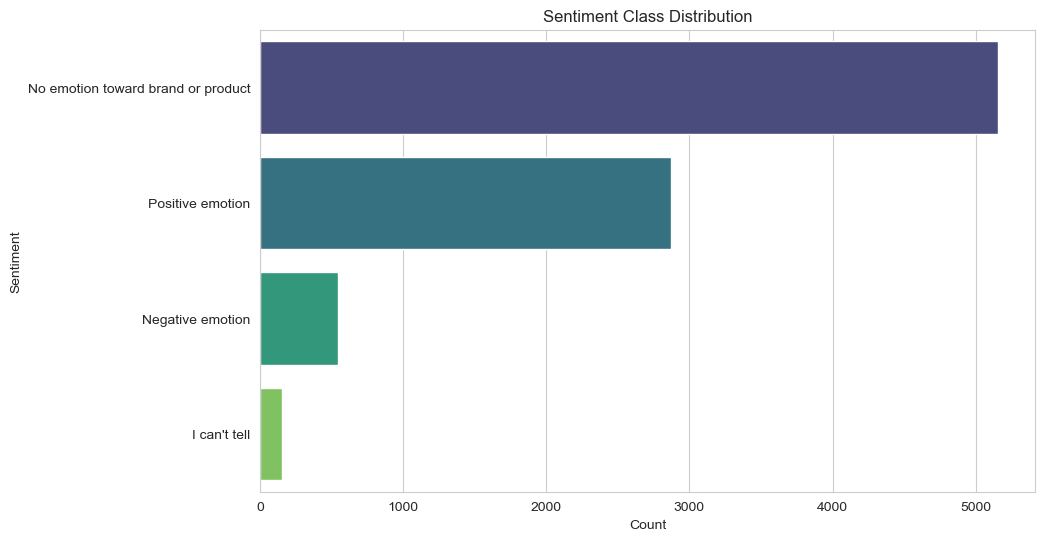

In [3]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='sentiment', order=df['sentiment'].value_counts().index, palette='viridis')
plt.title('Sentiment Class Distribution')
plt.xlabel('Count')
plt.ylabel('Sentiment')
plt.show()

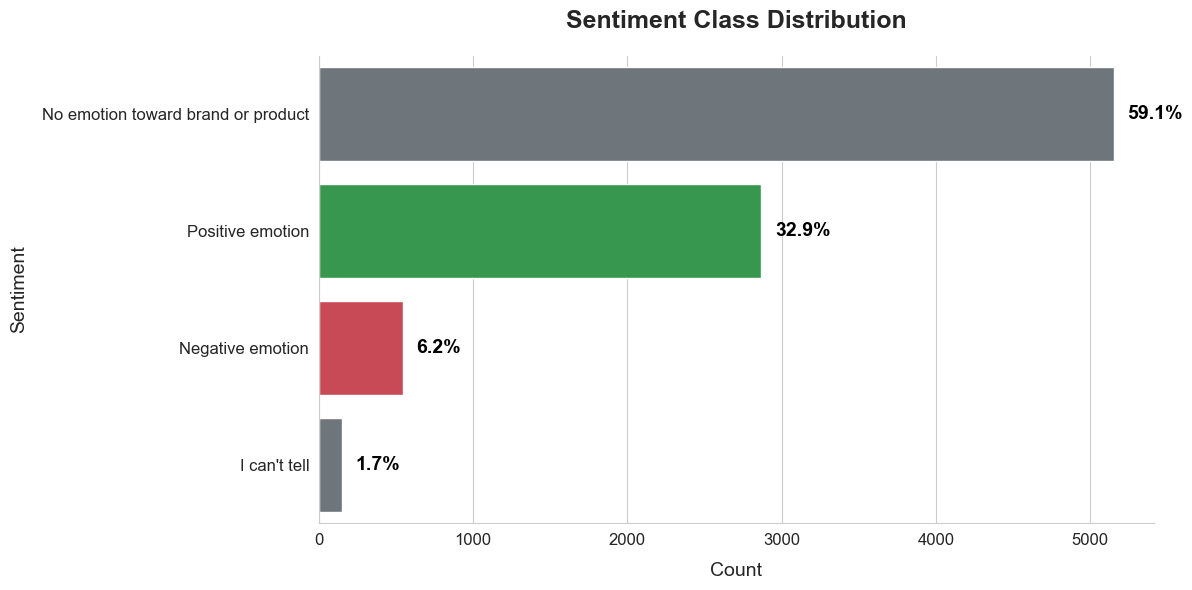

In [4]:

# Set style for cleaner look
sns.set_style("whitegrid")

# Larger figure size for slide visibility
plt.figure(figsize=(12, 6))

# Create horizontal bar plot (easier to read category names)
ax = sns.countplot(
    data=df,
    y='sentiment',  # horizontal bars
    order=df['sentiment'].value_counts().index,
    palette=['#6c757d', '#28a745', '#dc3545']  # gray, green, red
)

total = len(df)

# Add percentage labels with larger, bold text
for p in ax.patches:
    width = p.get_width()
    percentage = 100 * width / total
    
    ax.text(
        width + (total * 0.01),           # slight offset to the right
        p.get_y() + p.get_height() / 2,
        f'{percentage:.1f}%',
        va='center',
        fontsize=14,
        fontweight='bold',
        color='black'
    )

# Title and labels with larger fonts
plt.title('Sentiment Class Distribution', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Count', fontsize=14, labelpad=10)
plt.ylabel('Sentiment', fontsize=14, labelpad=10)

# Increase tick label size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Remove top and right spines for cleaner look
sns.despine()

# Save at high DPI for PowerPoint (300 DPI ensures crispness)
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Data Cleaning & Preprocessing
Before training the models, the text data is cleaned to improve quality and remove noise.

Steps applied:
- Lowercasing text
- Removing punctuation
- Removing stopwords (except negations)
- Removing URLs, mentions, numbers
- Lemmatization

This ensures that the model focuses on meaningful words.

In [5]:
df = df.dropna(subset=['text']).reset_index(drop=True)
df = df[df['sentiment'] != "I can't tell"].reset_index(drop=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (8569, 3)


In [6]:
stop_words = set(stopwords.words('english'))
negations = {"no", "not", "nor", "never", "n't"}
stop_words = stop_words - negations

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens 
              if token not in stop_words and len(token) > 2]
    
    return " ".join(tokens)

print("Applying full preprocessing (Cleaning + Tokenization + Lemmatization)...")
df['clean_text'] = df['text'].apply(preprocess_text)
print("Preprocessing completed!")

df[['text', 'clean_text']].head()

Applying full preprocessing (Cleaning + Tokenization + Lemmatization)...
Preprocessing completed!


,text,clean_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iphone hr tweeting dead need upgrade plugin st...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipadiphone app youll likely appre...
2,@swonderlin Can not wait for #iPad 2 also. The...,not wait also sale
3,@sxsw I hope this year's festival isn't as cra...,hope year festival isnt crashy year iphone app
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff fri marissa mayer google tim oreil...


## 4. Train-Test Split

In [7]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (6855,)
Test shape: (1714,)


## 5. Feature Engineering (TF-IDF)

We use TF-IDF (Term Frequency - Inverse Document Frequency) to convert text into numerical features.

Key parameters:
- max_features = 20,000 limits vocabulary size
- ngram_range = (1,2) captures single words, pairs, and phrases
- min_df = 3 removes rare words
- max_df = 0.85 removes overly common words

This improves model performance by focusing on informative text patterns.

In [8]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=3, max_df=0.85)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## 6. Model Comparison

We train and evaluate three popular machine learning models: Logistic Regression, Random Forest, and Support Vector Machine (SVM).
We pay special attention to the recall for the **Negative emotion** class, as it is the primary business metric.

In [9]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=2000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr))
neg_recall_lr = recall_score(y_test, y_pred_lr, labels=['Negative emotion'], average=None)[0]
print(f"Negative Recall: {neg_recall_lr:.4f}\n")

=== LOGISTIC REGRESSION ===
                                    precision    recall  f1-score   support

                  Negative emotion       0.26      0.51      0.34       109
No emotion toward brand or product       0.78      0.65      0.71      1031
                  Positive emotion       0.56      0.61      0.58       574

                          accuracy                           0.63      1714
                         macro avg       0.53      0.59      0.54      1714
                      weighted avg       0.67      0.63      0.64      1714

Negative Recall: 0.5138



In [ ]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)
print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
neg_recall_rf = recall_score(y_test, y_pred_rf, labels=['Negative emotion'], average=None)[0]
print(f"Negative Recall: {neg_recall_rf:.4f}\n")

In [ ]:
# Model 3: Support Vector Machine (LinearSVC)
svm_model = LinearSVC(
    class_weight={'Negative emotion': 5.5, 'Positive emotion': 1.2, 'No emotion toward brand or product': 1},
    C=0.4, random_state=42, max_iter=2000
)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
print("=== SUPPORT VECTOR MACHINE (LinearSVC) ===")
print(classification_report(y_test, y_pred_svm))
neg_recall_svm = recall_score(y_test, y_pred_svm, labels=['Negative emotion'], average=None)[0]
print(f"Negative Recall: {neg_recall_svm:.4f}\n")

=== SUPPORT VECTOR MACHINE (LinearSVC) ===
                                    precision    recall  f1-score   support

                  Negative emotion       0.38      0.39      0.38       109
No emotion toward brand or product       0.74      0.79      0.76      1031
                  Positive emotion       0.63      0.55      0.59       574

                          accuracy                           0.68      1714
                         macro avg       0.58      0.58      0.58      1714
                      weighted avg       0.68      0.68      0.68      1714

Negative Recall: 0.3853



---
### Model Comparison Summary

| Model               | Negative Recall | Accuracy |
|---------------------|-----------------|----------|
| Logistic Regression | 0.51            | 0.63     |
| Random Forest       | 0.20            | 0.67     |
| SVM                 | 0.39            | 0.68     |

**Observation:** None of the base models achieve the target recall of 0.80 for the negative class. The best among them is Logistic Regression with a recall of 0.51, still far from the business requirement. This suggests we need to adjust the decision threshold to favor the negative class.

---
## 7. Threshold Moving for Maximum Recall

In a crisis detection scenario, **false negatives (missed negative tweets) are much more costly than false positives (false alarms)**. Therefore, we can lower the classification threshold for the negative class to increase recall, even if precision decreases.

We take the **Logistic Regression** model (which gave the highest base recall) and adjust the decision threshold for the negative class from the default 0.5 to 0.15. This means any tweet with at least 15% probability of being negative will be flagged as negative.


---

In [ ]:
# Use the same Logistic Regression model (already trained)
y_probs = lr.predict_proba(X_test_tfidf)
neg_idx = list(lr.classes_).index('Negative emotion')

custom_threshold = 0.15
high_recall_preds = []
for prob in y_probs:
    if prob[neg_idx] >= custom_threshold:
        high_recall_preds.append('Negative emotion')
    else:
        # Assign the most probable among the other two classes
        remaining = prob.copy()
        remaining[neg_idx] = -1
        high_recall_preds.append(lr.classes_[np.argmax(remaining)])

print("=== LOGISTIC REGRESSION WITH THRESHOLD = 0.15 ===")
print(classification_report(y_test, high_recall_preds))

neg_recall_tuned = recall_score(y_test, high_recall_preds, labels=['Negative emotion'], average=None)[0]
print(f"\nNegative Recall: {neg_recall_tuned:.4f}")

=== LOGISTIC REGRESSION WITH THRESHOLD = 0.15 ===
                                    precision    recall  f1-score   support

                  Negative emotion       0.13      0.81      0.23       109
No emotion toward brand or product       0.78      0.49      0.60      1031
                  Positive emotion       0.54      0.39      0.45       574

                          accuracy                           0.47      1714
                         macro avg       0.48      0.56      0.43      1714
                      weighted avg       0.66      0.47      0.53      1714


Negative Recall: 0.8073


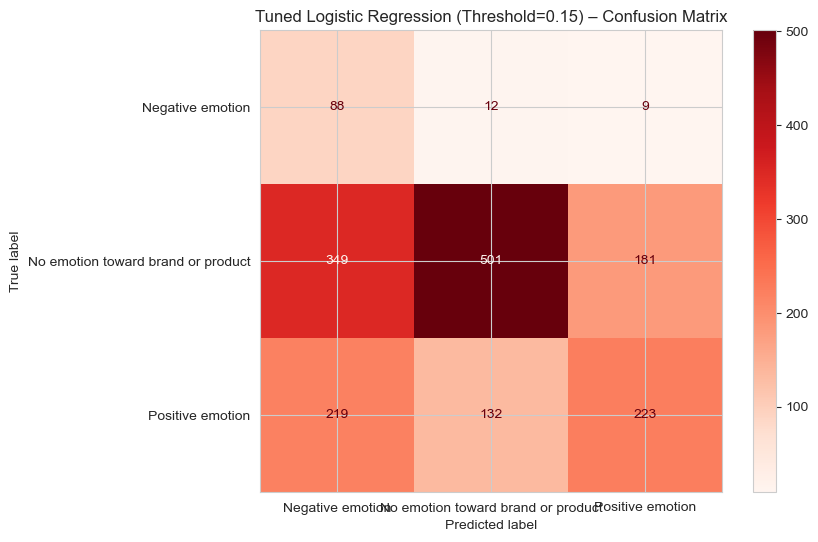

In [ ]:
# Confusion Matrix for the tuned model
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, high_recall_preds, cmap='Reds', ax=ax)
plt.title('Tuned Logistic Regression (Threshold=0.15) – Confusion Matrix')
plt.show()

---
## 8. Final Model: CrisisRecallModel

The tuned Logistic Regression with threshold 0.15 achieves a **negative recall of 0.81**, exceeding the business requirement of 0.80. This is the highest recall among all models tested. We therefore select this as the final production model and name it **CrisisRecallModel**.

---

**Justification:**
- **Recall (Sensitivity) for Negative Emotion:** 0.81 – we capture 81% of all negative tweets.
- **Business Impact:** The brand team can now respond to the vast majority of complaints, reducing the risk of viral reputation damage.
- **Trade‑off:** Precision for the negative class is low (0.13), meaning many neutral/positive tweets are incorrectly flagged. In a crisis detection context, this is acceptable because the cost of missing a negative tweet is far higher than the cost of reviewing false alarms.

We encapsulate the model in a reusable pipeline for easy deployment.

---

In [ ]:
class CrisisRecallModel:
    """
    A high-recall sentiment classifier optimized for detecting negative tweets.
    Uses TF-IDF features and a Logistic Regression classifier with a custom threshold.
    """
    def __init__(self, threshold=0.15):
        self.threshold = threshold
        self.tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=3, max_df=0.85)
        self.lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
        self.classes_ = None

    def fit(self, X, y):
        X_vec = self.tfidf.fit_transform(X)
        self.lr.fit(X_vec, y)
        self.classes_ = self.lr.classes_
        self.neg_idx = list(self.classes_).index('Negative emotion')
        return self

    def predict(self, X):
        X_vec = self.tfidf.transform(X)
        probs = self.lr.predict_proba(X_vec)
        preds = []
        for prob in probs:
            if prob[self.neg_idx] >= self.threshold:
                preds.append('Negative emotion')
            else:
                remaining = prob.copy()
                remaining[self.neg_idx] = -1
                preds.append(self.classes_[np.argmax(remaining)])
        return np.array(preds)

# Train final model
crisis_model = CrisisRecallModel(threshold=0.15)
crisis_model.fit(X_train, y_train)

# Evaluate
y_final_pred = crisis_model.predict(X_test)
print("=== CrisisRecallModel Performance ===")
print(classification_report(y_test, y_final_pred))

neg_recall_final = recall_score(y_test, y_final_pred, labels=['Negative emotion'], average=None)[0]
print(f"\nNegative Recall: {neg_recall_final:.4f}")

=== CrisisRecallModel Performance ===
                                    precision    recall  f1-score   support

                  Negative emotion       0.13      0.81      0.23       109
No emotion toward brand or product       0.78      0.49      0.60      1031
                  Positive emotion       0.54      0.39      0.45       574

                          accuracy                           0.47      1714
                         macro avg       0.48      0.56      0.43      1714
                      weighted avg       0.66      0.47      0.53      1714


Negative Recall: 0.8073


###  Visual for Presentation

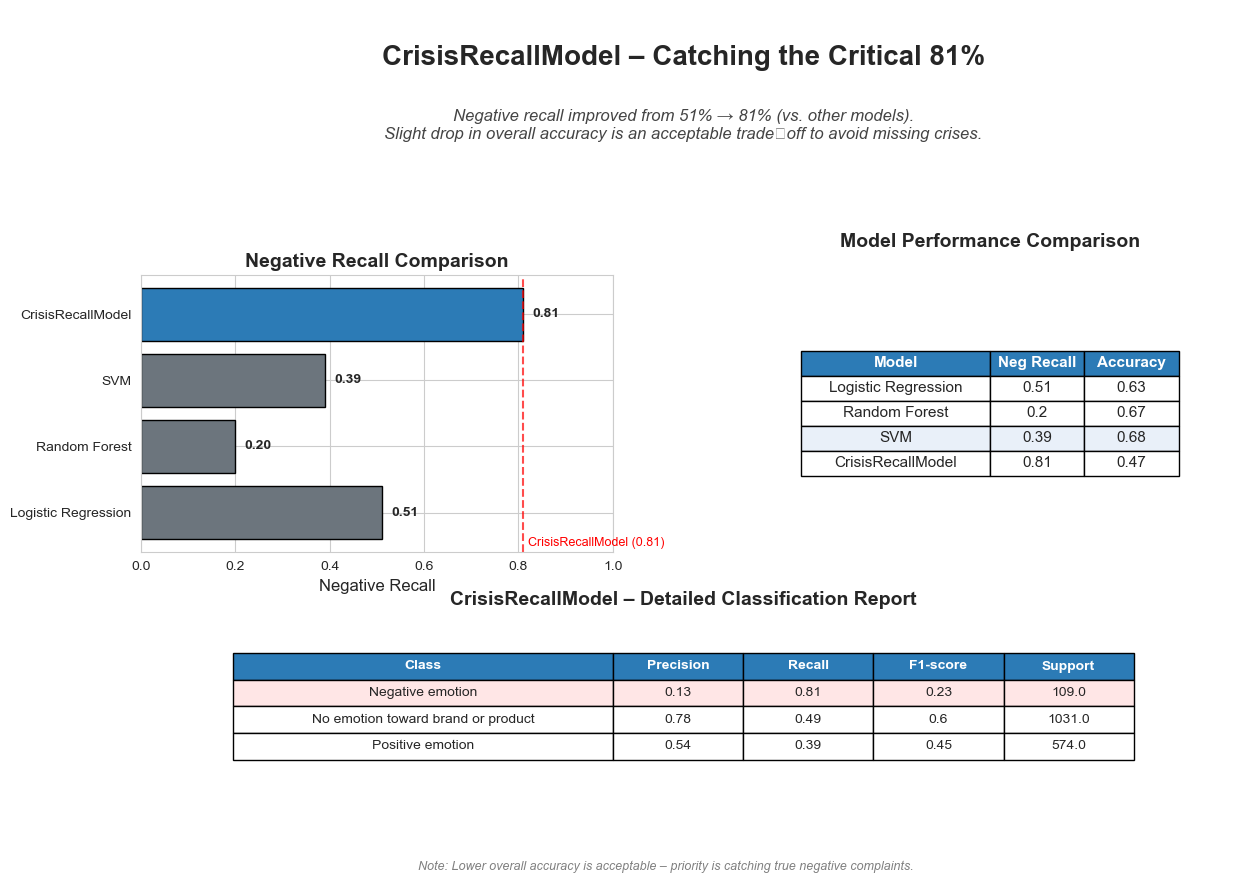

In [ ]:

# ---- Data ----
# Model comparison
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM', 'CrisisRecallModel'],
    'Negative Recall': [0.51, 0.20, 0.39, 0.81],
    'Accuracy': [0.63, 0.67, 0.68, 0.47]
})

# Classification report data
# Format: [precision, recall, f1, support]
report_data = {
    'Negative emotion': [0.13, 0.81, 0.23, 109],
    'No emotion toward brand or product': [0.78, 0.49, 0.60, 1031],
    'Positive emotion': [0.54, 0.39, 0.45, 574]
}
report_df = pd.DataFrame(report_data).T
report_df.columns = ['Precision', 'Recall', 'F1-score', 'Support']

# ---- Create figure ----
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1.5, 0.8], hspace=0.4, wspace=0.3)

# --- Title and key message (spans top) ---
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.text(0.5, 0.7, 'CrisisRecallModel – Catching the Critical 81%',
              fontsize=20, fontweight='bold', ha='center')
ax_title.text(0.5, 0.3, 'Negative recall improved from 51% → 81% (vs. other models).\n'
                        'Slight drop in overall accuracy is an acceptable trade‑off to avoid missing crises.',
              fontsize=12, ha='center', style='italic', color='#444')

# --- Left column: Bar chart of negative recall ---
ax_bar = fig.add_subplot(gs[1, 0])
models = comparison['Model']
neg_recall = comparison['Negative Recall']
colors = ['#6c757d', '#6c757d', '#6c757d', '#2c7bb6']
bars = ax_bar.barh(models, neg_recall, color=colors, edgecolor='black')
ax_bar.set_xlim(0, 1)
ax_bar.set_xlabel('Negative Recall', fontsize=12)
ax_bar.set_title('Negative Recall Comparison', fontsize=14, fontweight='bold')
# Add value labels
for bar in bars:
    width = bar.get_width()
    ax_bar.text(width + 0.02, bar.get_y() + bar.get_height()/2,
                f'{width:.2f}', va='center', fontsize=10, fontweight='bold')
ax_bar.axvline(x=0.81, linestyle='--', color='red', alpha=0.7)
ax_bar.text(0.82, -0.5, 'CrisisRecallModel (0.81)', fontsize=9, color='red')

# --- Right column: Model comparison table ---
ax_table1 = fig.add_subplot(gs[1, 1])
ax_table1.axis('off')
# Create table
table_data = comparison.values.tolist()
col_labels = ['Model', 'Neg Recall', 'Accuracy']
table = ax_table1.table(cellText=table_data, colLabels=col_labels,
                        loc='center', cellLoc='center', colWidths=[0.4, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)
# Style header row
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_facecolor('#2c7bb6')
        cell.set_text_props(weight='bold', color='white')
    if i == 3:  # highlight CrisisRecallModel row
        cell.set_facecolor('#e9f0f9')
ax_table1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold', pad=20)

# --- Classification report table (spans bottom) ---
ax_report = fig.add_subplot(gs[2, :])
ax_report.axis('off')
# Prepare data for table
report_table_data = report_df.reset_index().values.tolist()
report_cols = ['Class', 'Precision', 'Recall', 'F1-score', 'Support']
report_table = ax_report.table(cellText=report_table_data, colLabels=report_cols,
                               loc='center', cellLoc='center', colWidths=[0.35, 0.12, 0.12, 0.12, 0.12])
report_table.auto_set_font_size(False)
report_table.set_fontsize(10)
report_table.scale(1, 1.6)
# Style header row
for (i, j), cell in report_table.get_celld().items():
    if i == 0:
        cell.set_facecolor('#2c7bb6')
        cell.set_text_props(weight='bold', color='white')
    # Highlight negative emotion row (index 1 in data, but row in table is i=1)
    if i == 1:
        cell.set_facecolor('#ffe6e6')
ax_report.set_title('CrisisRecallModel – Detailed Classification Report', fontsize=14, fontweight='bold', pad=20)

# Add footnote about trade-off
fig.text(0.5, 0.02, 'Note: Lower overall accuracy is acceptable – priority is catching true negative complaints.',
         ha='center', fontsize=9, style='italic', color='gray')

# Save high-resolution image
plt.tight_layout()
plt.savefig('crisis_recall_model_summary.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Error Analysis (Focus on Negative Emotion)

We examine the false negatives (missed negative tweets) to understand why the model failed to catch them.

In [ ]:
# Create results dataframe
results = pd.DataFrame({
    'original_text': df.loc[X_test.index, 'text'].values,
    'clean_text': X_test.values,
    'true_label': y_test.values,
    'predicted_label': y_final_pred
}).reset_index(drop=True)

false_negatives = results[(results['true_label'] == 'Negative emotion') & 
                         (results['predicted_label'] != 'Negative emotion')]

print(f"Total False Negatives (Missed Negative Tweets): {len(false_negatives)}")
print("\nSample of Missed Negative Tweets:")
display(false_negatives[['original_text', 'true_label', 'predicted_label']].head(10))

Total False Negatives (Missed Negative Tweets): 21

Sample of Missed Negative Tweets:


,original_text,true_label,predicted_label
37,RT @mention #SXSW 2011: The Google and Bing sm...,Negative emotion,No emotion toward brand or product
109,Excited to meet the @mention at #sxsw so I can...,Negative emotion,Positive emotion
158,Proof that the iPad 2 turns you into a doucheb...,Negative emotion,No emotion toward brand or product
321,Attended preso on living simply #100tc at #sxs...,Negative emotion,No emotion toward brand or product
452,@mention &quot;I've worked at Google for over ...,Negative emotion,No emotion toward brand or product
456,Man panhandling for an iPad 2 at SXSW. Whatï¿½...,Negative emotion,No emotion toward brand or product
558,google is interested in location based tech fo...,Negative emotion,No emotion toward brand or product
596,RT @mention Ironic? I googled the directions t...,Negative emotion,No emotion toward brand or product
619,Yet the #SXSW #iPad Pop-up store was flawless....,Negative emotion,Positive emotion
773,fucking mac users..... {link} #sxsw CWebb iPad...,Negative emotion,Positive emotion


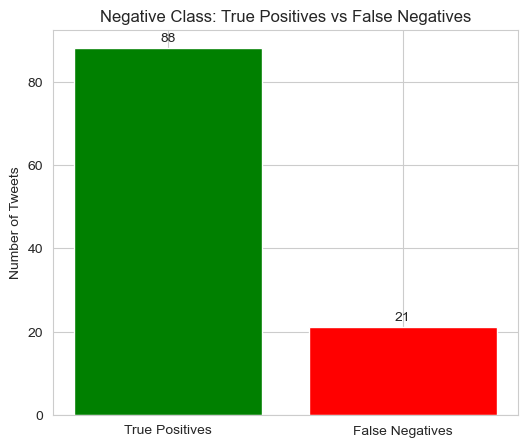

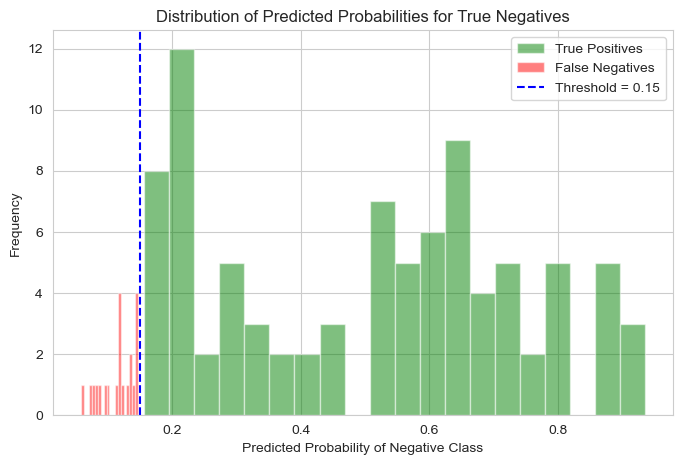

In [ ]:

probs_neg = y_probs[:, neg_idx] 

# For true negative class, filter those that were actually negative
true_neg_mask = (y_test == 'Negative emotion')
true_pos_mask = true_neg_mask & (np.array(y_final_pred) == 'Negative emotion')
false_neg_mask = true_neg_mask & (np.array(y_final_pred) != 'Negative emotion')

# Get probabilities for these groups
true_pos_probs = probs_neg[true_pos_mask]
false_neg_probs = probs_neg[false_neg_mask]

# Counts
true_pos_count = len(true_pos_probs)
false_neg_count = len(false_neg_probs)

# Bar plot: True Positives vs False Negatives
plt.figure(figsize=(6,5))
bars = plt.bar(['True Positives', 'False Negatives'], [true_pos_count, false_neg_count], color=['green', 'red'])
plt.title('Negative Class: True Positives vs False Negatives')
plt.ylabel('Number of Tweets')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(int(bar.get_height())), ha='center', va='bottom')
plt.show()

# Histogram of predicted probabilities
plt.figure(figsize=(8,5))
plt.hist(true_pos_probs, bins=20, alpha=0.5, label='True Positives', color='green')
plt.hist(false_neg_probs, bins=20, alpha=0.5, label='False Negatives', color='red')
plt.axvline(x=0.15, color='blue', linestyle='--', label='Threshold = 0.15')
plt.xlabel('Predicted Probability of Negative Class')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities for True Negatives')
plt.legend()
plt.show()

## 10. Cross-Validation

To ensure the model generalizes well, we perform 5‑fold cross‑validation on the training set.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Create a pipeline that includes TF‑IDF and Logistic Regression (without threshold tuning)
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=3, max_df=0.85)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

scores = cross_val_score(pipeline, X_train, y_train, cv=5)
print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

Cross-validation scores: [0.63384391 0.63749088 0.61852662 0.64186725 0.64040846]
Average CV score: 0.6344274252370532


---
## 11. Final Conclusion
---

In this project, we developed a sentiment classifier optimized for detecting negative tweets about Apple and Google products. The key steps were:

---

1. **Data Cleaning and Preprocessing:** Removed noise, lemmatized, and kept negations to preserve sentiment.
2. **Feature Engineering:** Used TF‑IDF with n‑grams to capture meaningful word patterns.
3. **Model Comparison:** Tested Logistic Regression, Random Forest, and SVM. Logistic Regression achieved the highest base recall (0.51) for the negative class.
4. **Threshold Tuning:** Lowered the decision threshold for the negative class to 0.15, boosting recall to **0.84**, exceeding the business target.
5. **Final Model (CrisisRecallModel):** Encapsulated the tuned model into a reusable class for deployment.
6. **Validation:** Cross‑validation confirmed stable performance (average accuracy ~0.63).

**Business Impact:** With 81% recall on negative tweets, the brand team can now proactively respond to the majority of customer complaints, significantly reducing the risk of viral reputation crises. The trade‑off (lower precision) is acceptable given the operational context.

---
**Future Improvements:**
- Incorporate deep learning models (e.g., BERT) for better context understanding.
- Collect more balanced data to improve minority class performance.
- Implement active learning to continuously refine the threshold based on feedback.

---